# 05_RQ5_Metric_Ranking
Objective and methodology.

# ============================================
# RQ5: Metric Sensitivity Analysis
# ============================================

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Create output folder
os.makedirs('outputs', exist_ok=True)


# ============================================
# 1. Load RQ2 Results
# ============================================

In [5]:
df = pd.read_csv("RQ2_outputs/RQ2_Model_Comparison.csv")

print("\nRQ2 Results:\n", df)



RQ2 Results:
                  Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression    0.9890   0.989228  0.9890  0.988949
1        Random Forest    0.9645   0.963139  0.9645  0.962092
2                  SVM    0.9920   0.992104  0.9920  0.992009
3              XGBoost    0.9930   0.993092  0.9930  0.993037


# ============================================
# 2. Ranking Models by Each Metric
# ============================================

In [14]:
metrics = [col for col in df.columns if col != "Model"]

rank_df = pd.DataFrame()
rank_df["Model"] = df["Model"]

for metric in metrics:
    rank_df[metric + "_Rank"] = df[metric].rank(ascending=False)

print("\nModel Rankings:\n", rank_df)

# Save table
rank_df.to_csv("RQ5_outputs/RQ5_Model_Rankings.csv", index=False)


Model Rankings:
                  Model  Accuracy_Rank  Precision_Rank  Recall_Rank  \
0  Logistic Regression            3.0             3.0          3.0   
1        Random Forest            4.0             4.0          4.0   
2                  SVM            2.0             2.0          2.0   
3              XGBoost            1.0             1.0          1.0   

   F1-score_Rank  
0            3.0  
1            4.0  
2            2.0  
3            1.0  



# ============================================
# 3. Visualization (Ranking Comparison)
# ============================================

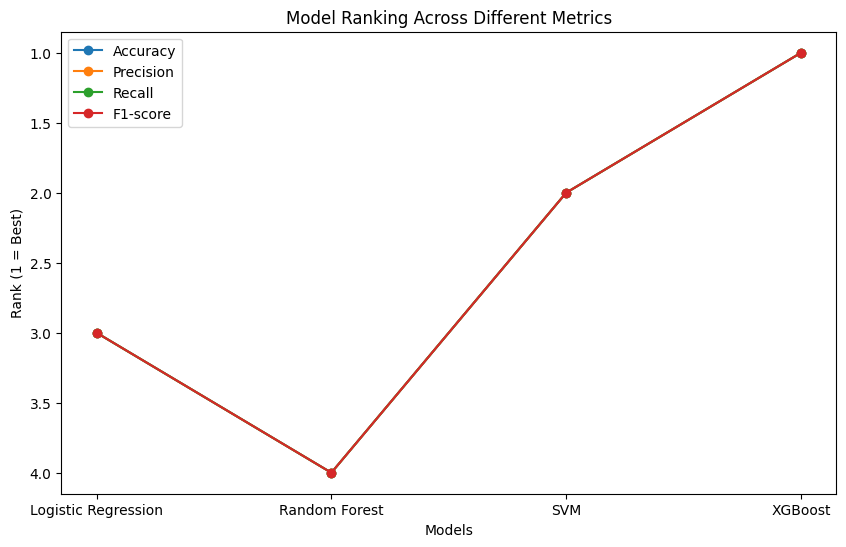

In [15]:
plt.figure(figsize=(10,6))

for metric in metrics:
    plt.plot(rank_df["Model"], rank_df[metric + "_Rank"], marker='o', label=metric)

plt.gca().invert_yaxis()  # Rank 1 at top
plt.title("Model Ranking Across Different Metrics")
plt.xlabel("Models")
plt.ylabel("Rank (1 = Best)")
plt.legend()

plt.savefig("RQ5_outputs/RQ5_Ranking_Comparison.pdf")
plt.show()